In [2]:
# Copyright 2024 Black Forest Labs and The HuggingFace Team. All rights reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '5'

import inspect
from typing import Any, Callable, Dict, List, Optional, Union

import PIL
from PIL import Image
import numpy as np
import torch
import transformers
from transformers import CLIPProcessor, CLIPModel, CLIPFeatureExtractor
from transformers import CLIPTextModel, CLIPTokenizer, T5EncoderModel, T5TokenizerFast

from diffusers.image_processor import VaeImageProcessor
from diffusers.loaders import FluxLoraLoaderMixin
from diffusers.models.autoencoders import AutoencoderKL
from diffusers.models.transformers import FluxTransformer2DModel
from diffusers.schedulers import FlowMatchEulerDiscreteScheduler
from diffusers.utils import (
    USE_PEFT_BACKEND,
    is_torch_xla_available,
    logging,
    replace_example_docstring,
    scale_lora_layers,
    unscale_lora_layers,
)
from diffusers.utils.torch_utils import randn_tensor
from diffusers.pipelines.pipeline_utils import DiffusionPipeline
from diffusers.pipelines.flux.pipeline_output import FluxPipelineOutput


PIL_INTERPOLATION = {
    "linear": PIL.Image.Resampling.BILINEAR,
    "bilinear": PIL.Image.Resampling.BILINEAR,
    "bicubic": PIL.Image.Resampling.BICUBIC,
    "lanczos": PIL.Image.Resampling.LANCZOS,
    "nearest": PIL.Image.Resampling.NEAREST,
}


import torchvision
from torchvision import transforms


import matplotlib.pyplot as plt
import matplotlib.cm as cm


if is_torch_xla_available():
    import torch_xla.core.xla_model as xm

    XLA_AVAILABLE = True
else:
    XLA_AVAILABLE = False


logger = logging.get_logger(__name__)  # pylint: disable=invalid-name

EXAMPLE_DOC_STRING = """
    Examples:
        ```py
        >>> import torch
        >>> from diffusers import FluxPipeline

        >>> pipe = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-schnell", torch_dtype=torch.bfloat16)
        >>> pipe.to("cuda")
        >>> prompt = "A cat holding a sign that says hello world"
        >>> # Depending on the variant being used, the pipeline call will slightly vary.
        >>> # Refer to the pipeline documentation for more details.
        >>> image = pipe(prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
        >>> image.save("flux.png")
        ```
"""


def calculate_shift(
    image_seq_len,
    base_seq_len: int = 256,
    max_seq_len: int = 4096,
    base_shift: float = 0.5,
    max_shift: float = 1.16,
):
    m = (max_shift - base_shift) / (max_seq_len - base_seq_len)
    b = base_shift - m * base_seq_len
    mu = image_seq_len * m + b
    return mu


# Copied from diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.retrieve_timesteps
def retrieve_timesteps(
    scheduler,
    num_inference_steps: Optional[int] = None,
    device: Optional[Union[str, torch.device]] = None,
    timesteps: Optional[List[int]] = None,
    sigmas: Optional[List[float]] = None,
    **kwargs,
):
    """
    Calls the scheduler's `set_timesteps` method and retrieves timesteps from the scheduler after the call. Handles
    custom timesteps. Any kwargs will be supplied to `scheduler.set_timesteps`.

    Args:
        scheduler (`SchedulerMixin`):
            The scheduler to get timesteps from.
        num_inference_steps (`int`):
            The number of diffusion steps used when generating samples with a pre-trained model. If used, `timesteps`
            must be `None`.
        device (`str` or `torch.device`, *optional*):
            The device to which the timesteps should be moved to. If `None`, the timesteps are not moved.
        timesteps (`List[int]`, *optional*):
            Custom timesteps used to override the timestep spacing strategy of the scheduler. If `timesteps` is passed,
            `num_inference_steps` and `sigmas` must be `None`.
        sigmas (`List[float]`, *optional*):
            Custom sigmas used to override the timestep spacing strategy of the scheduler. If `sigmas` is passed,
            `num_inference_steps` and `timesteps` must be `None`.

    Returns:
        `Tuple[torch.Tensor, int]`: A tuple where the first element is the timestep schedule from the scheduler and the
        second element is the number of inference steps.
    """
    if timesteps is not None and sigmas is not None:
        raise ValueError("Only one of `timesteps` or `sigmas` can be passed. Please choose one to set custom values")
    if timesteps is not None:
        accepts_timesteps = "timesteps" in set(inspect.signature(scheduler.set_timesteps).parameters.keys())
        if not accepts_timesteps:
            raise ValueError(
                f"The current scheduler class {scheduler.__class__}'s `set_timesteps` does not support custom"
                f" timestep schedules. Please check whether you are using the correct scheduler."
            )
        scheduler.set_timesteps(timesteps=timesteps, device=device, **kwargs)
        timesteps = scheduler.timesteps
        num_inference_steps = len(timesteps)
    elif sigmas is not None:
        accept_sigmas = "sigmas" in set(inspect.signature(scheduler.set_timesteps).parameters.keys())
        if not accept_sigmas:
            raise ValueError(
                f"The current scheduler class {scheduler.__class__}'s `set_timesteps` does not support custom"
                f" sigmas schedules. Please check whether you are using the correct scheduler."
            )
        scheduler.set_timesteps(sigmas=sigmas, device=device, **kwargs)
        timesteps = scheduler.timesteps
        num_inference_steps = len(timesteps)
    else:
        scheduler.set_timesteps(num_inference_steps, device=device, **kwargs)
        timesteps = scheduler.timesteps
    return timesteps, num_inference_steps




def image2tensor(imagepath):
    # image process setting and module
    size = 512
    interpolation="bicubic"
    flip_p=1
    center_crop=False

    interpolation = {
        "linear": PIL_INTERPOLATION["linear"],
        "bilinear": PIL_INTERPOLATION["bilinear"],
        "bicubic": PIL_INTERPOLATION["bicubic"],
        "lanczos": PIL_INTERPOLATION["lanczos"],
    }[interpolation]

    flip_transform = transforms.RandomHorizontalFlip(flip_p)

    # load image and preprocess 
    image = Image.open(imagepath)

    if not image.mode == "RGB":
        image = image.convert("RGB")

    img = np.array(image).astype(np.uint8)

    if center_crop:
        crop = min(img.shape[0], img.shape[1])
        (
            h,
            w,
        ) = (
            img.shape[0],
            img.shape[1],
        )
        img = img[(h - crop) // 2 : (h + crop) // 2, (w - crop) // 2 : (w + crop) // 2]


    image = Image.fromarray(img)
    image = image.resize((size, size), resample=interpolation)

    image = flip_transform(image)
    image = np.array(image).astype(np.uint8)
    image = (image / 127.5 - 1.0).astype(np.float32)

    example = {}
    example["pixel_values"] = torch.from_numpy(image).permute(2, 0, 1).to(device)
    #print(example["pixel_values"].shape) # torch.Size([3, 512, 512])

    imagetensor =  example["pixel_values"]

    return imagetensor


def image_pt2pil(img): # input image tensor shoud be of shape 3,512,512
    input_img_torch_resized = img.permute(1, 2, 0)
    input_img_np = input_img_torch_resized.detach().cpu().numpy()
    input_img_np = (input_img_np * 255).astype(np.uint8)
    return Image.fromarray((input_img_np).astype(np.uint8)) 



/home/zy3724/miniconda3/envs/flatten/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/zy3724/miniconda3/envs/flatten/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/home/zy3724/miniconda3/envs/flatten/lib/python3.11/site-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
/home/zy3724/miniconda3/envs/flatten/lib/python3.11/site-packages/xformers/ops/fmha/flash.py:344: FutureW

In [3]:
from diffusers_local.pipelines.flux.pipeline_flux import FluxPipeline

# from huggingface_hub import login

# # Log in using your Hugging Face token
# login(token="YOUR_HF_TOKEN", add_to_git_credential=True)

model_id = "black-forest-labs/FLUX.1-schnell" #you can also use `black-forest-labs/FLUX.1-dev`

pipe = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-schnell", torch_dtype=torch.bfloat16).to("cuda")
#pipe.enable_model_cpu_offload() #save some VRAM by offloading the model to CPU. Remove this if you have enough GPU power

#d_model = torch.hub.load('./ZoeDepth', 'ZoeD_N', source='local', pretrained=True).to('cuda')

# def d(im):
#     return d_model.infer_pil(im)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


# set up

In [4]:
file_path_blur = os.path.join('/home/zy3724/git_repos/flatten/video_samples/test_pairs/quality100_85/image.jpg')
file_path_piscart = os.path.join('/home/zy3724/git_repos/flatten/video_samples/test_pairs/quality100_85/image_enhanced.jpg')

file_path_blur = os.path.join('/home/zy3724/git_repos/flatten/video_samples/test_pairs/size32_102/image.jpg')
file_path_piscart = os.path.join('/home/zy3724/git_repos/flatten/video_samples/test_pairs/size32_102/image_enhanced.jpg')

file_path_blur = os.path.join('/home/zy3724/git_repos/flatten/video_samples/distributiontest/image_.jpg')
file_path_piscart = os.path.join('/home/zy3724/git_repos/flatten/video_samples/distributiontest/image.png')
file_path_piscart2 = os.path.join('/home/zy3724/git_repos/flatten/video_samples/test_pairs/size64_0/image_enhanced_mag.jpg')

file_path = '/home/zy3724/git_repos/flatten/image/glassgirl.png'


## encode input image

/home/zy3724/miniconda3/envs/flatten/lib/python3.11/site-packages/diffusers/image_processor.py:627: FutureWarning: the output_type PIL is outdated and has been set to `np`. Please make sure to set it to one of these instead: `pil`, `np`, `pt`, `latent`
  deprecate("Unsupported output_type", "1.0.0", deprecation_message, standard_warn=False)


(512, 512, 3)

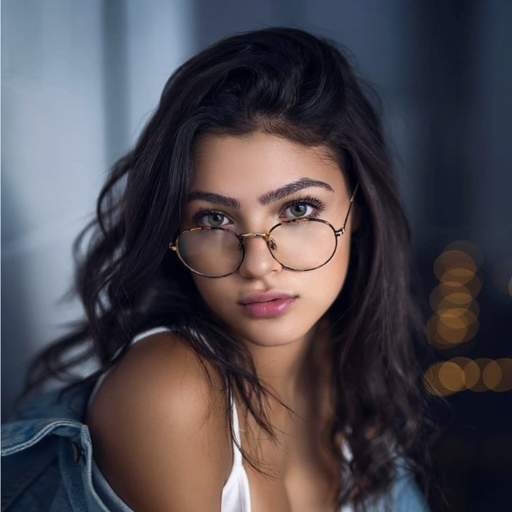

(512, 512, 3)

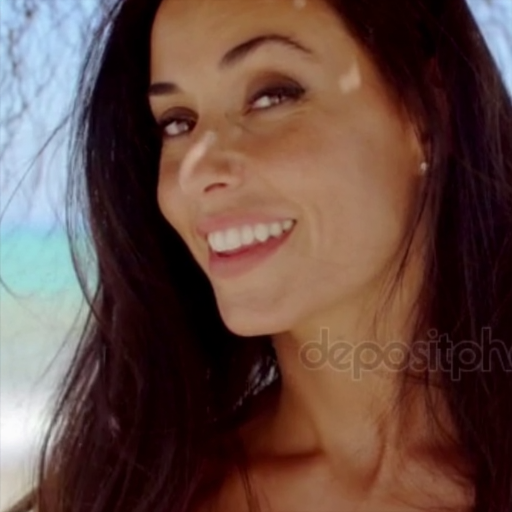

(512, 512, 3)

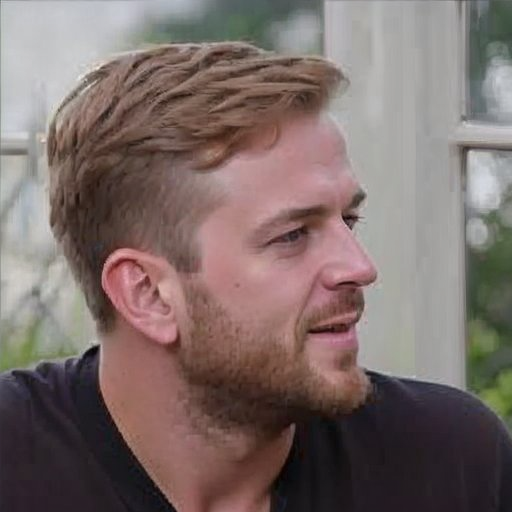

In [5]:
from PIL import Image

with torch.no_grad(): 
    device = pipe.device


    file_path = os.path.join('/home/zy3724/git_repos/flatten/image/glassgirl.png')


    img = Image.open(file_path).convert('RGB')
    img = img.resize((512, 512))
    # img.save(file_path)
    original_width, original_height = img.size
    image_processor = VaeImageProcessor()
    image = image_processor.preprocess(img, height=original_height, width=original_width).to(torch.bfloat16).to('cuda')
    latents = pipe.vae.encode(image)[0].sample()
    latents = (latents - pipe.vae.config.shift_factor)*pipe.vae.config.scaling_factor
    latents_target = pipe._pack_latents(latents, latents.shape[0], latents.shape[1], latents.shape[2], latents.shape[3])
    latents_target_1 = latents_target


    latents_target_ = pipe._unpack_latents(latents_target, original_height, original_width, pipe.vae_scale_factor)
    latents_target_ = (latents_target_ / pipe.vae.config.scaling_factor) + pipe.vae.config.shift_factor
    image = pipe.vae.decode(latents_target_, return_dict=False)[0]
    image = pipe.image_processor.postprocess(image, output_type="PIL")
    display(image[0].shape)
    numpy_array = (image[0] * 255).astype(np.uint8)
    pil_image = Image.fromarray(numpy_array)
    display(pil_image)



    #file_path = os.path.join('/home/zy3724/git_repos/flatten/metric_dataset/recolor/data/wedding/image_blend.png')

    img = Image.open(file_path_piscart).convert('RGB')
    img = img.resize((512, 512))
    original_width, original_height = img.size
    image_processor = VaeImageProcessor()
    image = image_processor.preprocess(img, height=original_height, width=original_width).to(torch.bfloat16).to('cuda')
    latents = pipe.vae.encode(image)[0].sample()
    latents = (latents - pipe.vae.config.shift_factor)*pipe.vae.config.scaling_factor
    latents_target = pipe._pack_latents(latents, latents.shape[0], latents.shape[1], latents.shape[2], latents.shape[3])
    latents_target_2 = latents_target


    latents_target_ = pipe._unpack_latents(latents_target, original_height, original_width, pipe.vae_scale_factor)
    latents_target_ = (latents_target_ / pipe.vae.config.scaling_factor) + pipe.vae.config.shift_factor
    image = pipe.vae.decode(latents_target_, return_dict=False)[0]
    image = pipe.image_processor.postprocess(image, output_type="PIL")
    display(image[0].shape)
    numpy_array = (image[0] * 255).astype(np.uint8)
    pil_image = Image.fromarray(numpy_array)
    display(pil_image)






    img = Image.open(file_path_piscart2).convert('RGB')
    img = img.resize((512, 512))
    #img.save('/home/zy3724/git_repos/flatten/metric_dataset/recolor/data/makeup/image_blend.png')
    original_width, original_height = img.size
    image_processor = VaeImageProcessor()
    image = image_processor.preprocess(img, height=original_height, width=original_width).to(torch.bfloat16).to('cuda')
    latents = pipe.vae.encode(image)[0].sample()
    latents = (latents - pipe.vae.config.shift_factor)*pipe.vae.config.scaling_factor
    latents_target = pipe._pack_latents(latents, latents.shape[0], latents.shape[1], latents.shape[2], latents.shape[3])
    latents_target_3 = latents_target


    latents_target_ = pipe._unpack_latents(latents_target, original_height, original_width, pipe.vae_scale_factor)
    latents_target_ = (latents_target_ / pipe.vae.config.scaling_factor) + pipe.vae.config.shift_factor
    image = pipe.vae.decode(latents_target_, return_dict=False)[0]
    image = pipe.image_processor.postprocess(image, output_type="PIL")
    display(image[0].shape)
    numpy_array = (image[0] * 255).astype(np.uint8)
    pil_image = Image.fromarray(numpy_array)
    display(pil_image)


    


In [5]:
print(latents.shape[1])

16


## pipe set up

In [6]:
from PIL import Image

with torch.no_grad(): 
    height = 512
    width = 512

    # pipe prompt preparation
    prompt = 'a flying kitten, high quality, 4K'
    output_type = "pil"
    seed = 42
    testimage = pipe(
        prompt,
        guidance_scale=3.5,
        height = height,
        width = width, 
        output_type="pil",
        num_inference_steps=10, #use a larger number if you are using [dev]
        generator=torch.Generator("cuda").manual_seed(seed)
    ).images[0]
    #testimage.save("testimage.png")


    # 4. Prepare latent variables
    num_channels_latents = pipe.transformer.config.in_channels // 4
    generator=torch.Generator("cuda").manual_seed(seed)
    latents_rand, latent_image_ids = pipe.prepare_latents(
        1 * 1, # batch_size * num_images_per_prompt
        num_channels_latents,
        height,
        width,
        pipe.prompt_embeds.dtype,
        pipe.device,
        generator,
        None,
    )

    num_inference_steps = 100


    # 5. Prepare timesteps
    sigmas = np.linspace(1.0, 1 / num_inference_steps, num_inference_steps)
    image_seq_len = latents.shape[1]
    mu = calculate_shift(
        image_seq_len,
        pipe.scheduler.config.base_image_seq_len,
        pipe.scheduler.config.max_image_seq_len,
        pipe.scheduler.config.base_shift,
        pipe.scheduler.config.max_shift,
    )
    timesteps = None
    timesteps, num_inference_steps = retrieve_timesteps(
        pipe.scheduler,
        num_inference_steps,
        device,
        timesteps,
        sigmas,
        mu=mu,
    )
    num_warmup_steps = max(len(timesteps) - num_inference_steps * pipe.scheduler.order, 0)
    pipe._num_timesteps = len(timesteps)


def display_latent(latent):
    latent_ = pipe._unpack_latents(latent, height, width, pipe.vae_scale_factor)
    latent_ = (latent_ / pipe.vae.config.scaling_factor) + pipe.vae.config.shift_factor
    image = pipe.vae.decode(latent_, return_dict=False)[0]
    image = pipe.image_processor.postprocess(image, output_type=output_type)
    display(image[0])

    return image[0]


guidance = None


here


  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
print(timesteps)
print(pipe.scheduler.sigmas)

# fixpoint

## original fix point

### target fix point

In [ ]:
idx = 60
latents = latents_target_1
latents_target = torch.clone(latents).to(latents.dtype).to(latents.device)

# display_latent(latents_target)
with torch.no_grad(): 
    torch.manual_seed(0)
    V = (latents_target).to(latents.dtype).to(latents.device)
    display_latent(V)
    idx = idx

    V_history = []
    noise_pred_history = []
    V_predict_history = []


    for b in range(5): # 30

        # print(torch.norm(V))
        timestep = timesteps[idx].to(latents.dtype)
        timestep = timestep.repeat(latents.shape[0])
        noise_pred = pipe.transformer(
            hidden_states=V,
            # YiYi notes: divide it by 1000 for now because we scale it by 1000 in the transforme rmodel (we should not keep it but I want to keep the inputs same for the model for testing)
            timestep=timestep / 1000,
            guidance=guidance,
            pooled_projections=pipe.pooled_prompt_embeds,
            encoder_hidden_states=pipe.prompt_embeds,
            txt_ids=pipe.text_ids,
            img_ids=latent_image_ids,
            joint_attention_kwargs=pipe.joint_attention_kwargs,
            return_dict=False,
        )[0]

        V_predict = V + (pipe.scheduler.sigmas[-1] - pipe.scheduler.sigmas[idx]) * noise_pred
        

        V_history.append(V)
        noise_pred_history.append(noise_pred)
        V_predict_history.append(V_predict)


        print( '---- below is V --------------------------------------' )
        # display_latent( V )
        # V_ = pipe._unpack_latents(V, height, width, pipe.vae_scale_factor)
        # V_ = (V_ / pipe.vae.config.scaling_factor) + pipe.vae.config.shift_factor
        # image = pipe.vae.decode(V_, return_dict=False)[0]
        # image = pipe.image_processor.postprocess(image, output_type=output_type)
        # display(image[0])

        print( f'---- below is V_predict {len(V_predict_history)-1}------------------------------' )
        # display_latent( V_predict )
        # V_predict_ = pipe._unpack_latents(V_predict, height, width, pipe.vae_scale_factor)
        # V_predict_ = (V_predict_ / pipe.vae.config.scaling_factor) + pipe.vae.config.shift_factor
        # image = pipe.vae.decode(V_predict_, return_dict=False)[0]
        # image = pipe.image_processor.postprocess(image, output_type=output_type)
        # display(image[0])

        print( '----------------------------------------------------------' )
        print( 'next iteration' )
        print( '----------------------------------------------------------' )


        #V = latents_target_1 - ( (pipe.scheduler.sigmas[-1] - pipe.scheduler.sigmas[idx]) * noise_pred )         # if b == 0:

        V = latents_target_1 - ( (pipe.scheduler.sigmas[-1] - pipe.scheduler.sigmas[idx]) * noise_pred ) 

        

## purple center visual

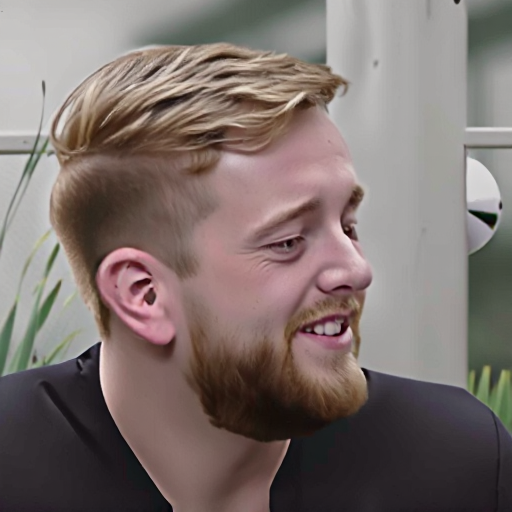

In [32]:
with torch.no_grad(): 
    timestep = timesteps[idx].expand(latents.shape[0]).to(latents.dtype)

    # # Manually specify indices and take elements from V_history
    # selected_indices = [7, 13, 16, 25, 31, 37, 43, 49]  # Example indices
    # V_selected = [V_history[i] for i in selected_indices if i < len(V_history)]
    # # Convert the list to a tensor
    # V_mean = torch.stack(V_selected).mean(dim=0)


    V_even =    V_history[11::2]
    #V_even =  V_history[2+36::6] + V_history[5::6]

    
    #V_even =  [V_history[47]]


    V_mean = torch.stack(V_even).mean(dim=0)


    noise_pred_mean = pipe.transformer(
        hidden_states= V_mean,
        timestep=timestep / 1000,  # Dividing timestep by 1000 for testing as per your code
        guidance=guidance,
        pooled_projections=pipe.pooled_prompt_embeds,
        encoder_hidden_states=pipe.prompt_embeds,
        txt_ids=pipe.text_ids,
        img_ids=latent_image_ids,
        joint_attention_kwargs=pipe.joint_attention_kwargs,
        return_dict=False,
    )[0]
    V_predict_mean = V_mean + (pipe.scheduler.sigmas[-1] - pipe.scheduler.sigmas[idx]) * noise_pred_mean
    display_latent(V_predict_mean)



## visualization

In [ ]:
with torch.no_grad(): 
    display_latent( noise_predict_track[0] )

    display_latent( noise_predict_track[49] )


In [ ]:
idx/100

### inversion ablation

In [ ]:
print(latents_target_2.shape)

In [ ]:
indices = list(range(99, 59, -1))
#indices = [99, 70]

#indices = list(range(99, 59, -4))[:10]  # Take 10 evenly spaced steps from 99 to 60
indices = list(range(99, 60, -4))[:10]  # Take 10 evenly spaced steps from 99 to 60

indices = [99, 80, 70, 60] # Take 4 evenly spaced steps from 99 to 60

indices = [99, 60] # Take 4 evenly spaced steps from 99 to 60

latents = latents_target_2 
latents_target = torch.clone(latents).to(latents.dtype).to(latents.device)



with torch.no_grad(): 
    torch.manual_seed(0)
    V = (latents_target).to(latents.dtype).to(latents.device)

    V_history = []
    noise_pred_history = []
    V_predict_history = []


    for i in range(len(indices)-1):

        print(torch.norm(V))
        print(i)

        guidance = None

        noise_pred = pipe.transformer(
            hidden_states=V,
            # YiYi notes: divide it by 1000 for now because we scale it by 1000 in the transforme rmodel (we should not keep it but I want to keep the inputs same for the model for testing)
            timestep=timesteps[indices[i]].expand(latents.shape[0]).to(latents.dtype) / 1000,
            guidance=guidance,
            pooled_projections=pipe.pooled_prompt_embeds,
            encoder_hidden_states=pipe.prompt_embeds,
            txt_ids=pipe.text_ids,
            img_ids=latent_image_ids,
            joint_attention_kwargs=pipe.joint_attention_kwargs,
            return_dict=False,
        )[0]

        V = V + (pipe.scheduler.sigmas[indices[i+1]] - pipe.scheduler.sigmas[indices[i]]) * noise_pred
    

with torch.no_grad(): 
        noise_pred = pipe.transformer(
            hidden_states=V,
            # YiYi notes: divide it by 1000 for now because we scale it by 1000 in the transforme rmodel (we should not keep it but I want to keep the inputs same for the model for testing)
            timestep=timesteps[indices[i+1]].expand(latents.shape[0]).to(latents.dtype) / 1000,
            guidance=guidance,
            pooled_projections=pipe.pooled_prompt_embeds,
            encoder_hidden_states=pipe.prompt_embeds,
            txt_ids=pipe.text_ids,
            img_ids=latent_image_ids,
            joint_attention_kwargs=pipe.joint_attention_kwargs,
            return_dict=False,
        )[0]

        V_predict = V + (pipe.scheduler.sigmas[-1] - pipe.scheduler.sigmas[indices[i+1]]) * noise_pred
        display_latent( V_predict )

### linear ablation ablation

/home/zy3724/miniconda3/envs/flatten/lib/python3.11/site-packages/diffusers/image_processor.py:627: FutureWarning: the output_type PIL is outdated and has been set to `np`. Please make sure to set it to one of these instead: `pil`, `np`, `pt`, `latent`
  deprecate("Unsupported output_type", "1.0.0", deprecation_message, standard_warn=False)


(512, 512, 3)

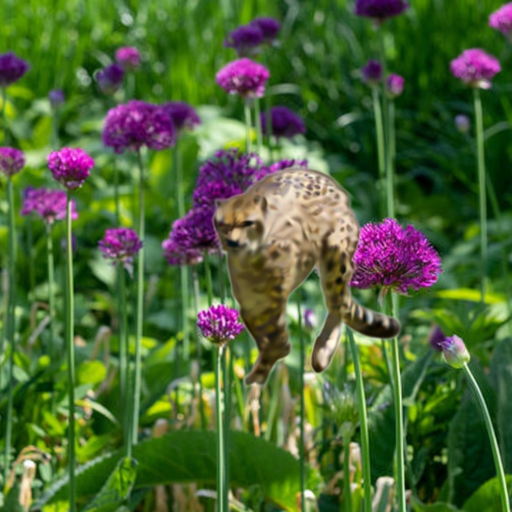

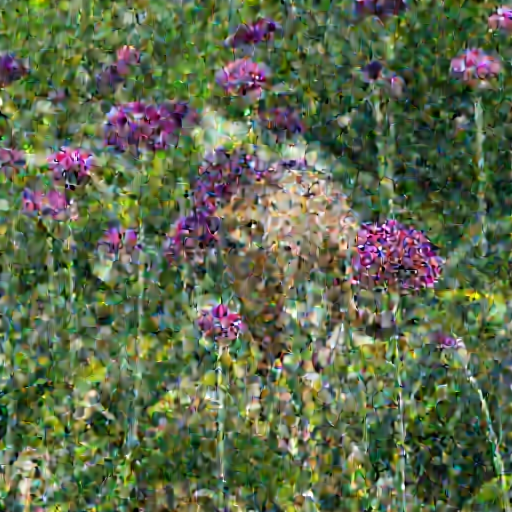

In [24]:
# linear ablation study


with torch.no_grad(): 
    device = pipe.device


    file_path = file_path
    file_path = '/home/zy3724/git_repos/dualdreamer/harmonydreamer/local_visualization_cache/a_target.png'
    img = Image.open(file_path).convert('RGB')
    img = img.resize((512, 512))
    #img.save('/home/zy3724/git_repos/flatten/metric_dataset/recolor/data/makeup/image_512.png')
    original_width, original_height = img.size
    image_processor = VaeImageProcessor()
    image = image_processor.preprocess(img, height=original_height, width=original_width).to(torch.bfloat16).to('cuda')
    image1 = image
    latents = pipe.vae.encode(image)[0].sample()
    latent1 = latents
    latents = (latents - pipe.vae.config.shift_factor)*pipe.vae.config.scaling_factor
    latents_target = pipe._pack_latents(latents, latents.shape[0], latents.shape[1], latents.shape[2], latents.shape[3])
    latents_target_1 = latents_target


    latents_target_ = pipe._unpack_latents(latents_target, original_height, original_width, pipe.vae_scale_factor)
    latents_target_ = (latents_target_ / pipe.vae.config.scaling_factor) + pipe.vae.config.shift_factor
    image = pipe.vae.decode(latents_target_, return_dict=False)[0]
    image = pipe.image_processor.postprocess(image, output_type="PIL")
    display(image[0].shape)
    numpy_array = (image[0] * 255).astype(np.uint8)
    pil_image = Image.fromarray(numpy_array)
    display(pil_image)





idx = 60
torch.manual_seed(2)
# Create a linear combination of torch normal and latents_target_1
blend_ratio = idx / 100.0
    
# Generate random noise with the same shape as latents_target_1
random_noise = torch.randn_like(latents_target_1).to(latents.device).to(latents.dtype)

random_noise_2 = torch.randn_like(latents_target_1).to(latents.device).to(latents.dtype)

# Create the linear combination
P_test = 1*(1-blend_ratio) * (random_noise)  + (blend_ratio) * latents_target_1

    
# Visualize the result
with torch.no_grad():
    display_latent(P_test)



In [30]:
print(pipe.vae.config.shift_factor)

0.1159


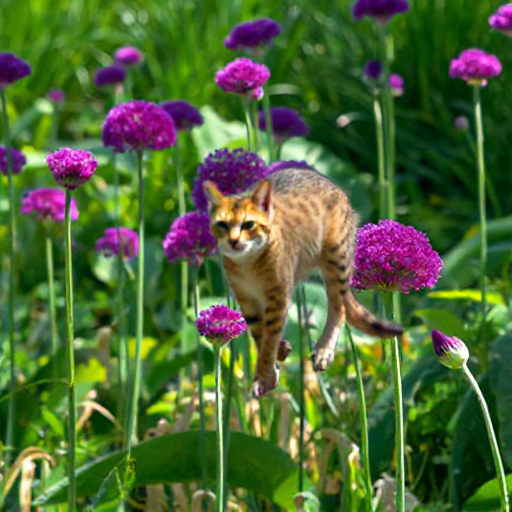

In [15]:
V_test = P_test

with torch.no_grad():
    timestep = timesteps[idx].expand(latents.shape[0]).to(latents.dtype)

    noise_pred_test = pipe.transformer(
        hidden_states= V_test,
        timestep=timestep / 1000,  # Dividing timestep by 1000 for testing as per your code
        guidance=None,
        pooled_projections=pipe.pooled_prompt_embeds,
        encoder_hidden_states=pipe.prompt_embeds,
        txt_ids=pipe.text_ids,
        img_ids=latent_image_ids,
        joint_attention_kwargs=pipe.joint_attention_kwargs,
        return_dict=False,
    )[0]
    V_predict_test = V_test + (pipe.scheduler.sigmas[-1] - pipe.scheduler.sigmas[idx]) * noise_pred_test
    image_sde = display_latent(V_predict_test)


In [31]:
print(V_test)
print(latents_target_1)
print(pipe.vae.dtype)

tensor([[[-0.5469, -0.5938, -0.1816,  ...,  0.6719,  0.8594,  0.1523],
         [-0.1094,  0.2520, -0.4043,  ...,  0.5938,  0.3691,  0.4570],
         [-0.7969, -1.5312,  0.0225,  ...,  0.8047, -0.4199,  0.3477],
         ...,
         [ 0.2656,  0.2656,  0.0967,  ...,  0.7383,  0.5547,  0.8828],
         [-0.4199, -0.0703,  0.4258,  ...,  1.2891,  0.3652,  1.0156],
         [-0.7070, -0.1118,  0.0605,  ..., -0.3359,  0.3770,  0.0535]]],
       device='cuda:0', dtype=torch.bfloat16)
tensor([[[-0.9258, -0.6016, -0.7734,  ...,  0.1709,  0.2021,  0.8359],
         [-0.5195,  0.1406, -0.9414,  ...,  0.4824,  0.1572, -0.0569],
         [-0.9258, -1.5234, -0.3887,  ...,  0.7188,  0.0908,  0.2969],
         ...,
         [ 0.3477,  0.2197,  0.2158,  ...,  1.3125,  0.8398,  1.0234],
         [-0.6953, -0.1943, -0.1177,  ...,  0.7031,  0.8789,  0.8242],
         [ 0.0569,  0.0220, -0.1631,  ..., -0.4141,  0.6758, -0.0933]]],
       device='cuda:0', dtype=torch.bfloat16)
torch.bfloat16


In [11]:
# 6. Denoising loop
# with self.progress_bar(total=num_inference_steps) as progress_bar:

# latents = torch.clone(P_track[-1]).to(latents.device).to(latents.dtype)
latents = torch.clone(P_test).to(latents.device).to(latents.dtype)

#latents = torch.clone(V_mean).to(latents.device).to(latents.dtype)

# latents = torch.clone(V).to(latents.device).to(latents.dtype)


#latents = torch.clone(V_history[21]).to(latents.device).to(latents.dtype)


with torch.no_grad():
    for i, t in enumerate(timesteps[idx:-1]):
        # if self.interrupt:
        #     continue

        print(f'timestep is {t}')
        # broadcast to batch dimension in a way that's compatible with ONNX/Core ML
        timestep = t.expand(latents.shape[0]).to(latents.dtype)

        # handle guidance
        if pipe.transformer.config.guidance_embeds:
            guidance = torch.tensor([pipe.guidance_scale], device=device)
            guidance = guidance.expand(latents.shape[0])
        else:
            guidance = None



        noise_pred = pipe.transformer(
            hidden_states=latents,
            # YiYi notes: divide it by 1000 for now because we scale it by 1000 in the transforme rmodel (we should not keep it but I want to keep the inputs same for the model for testing)
            timestep=timestep / 1000,
            guidance=guidance,
            pooled_projections=pipe.pooled_prompt_embeds,
            encoder_hidden_states=pipe.prompt_embeds,
            txt_ids=pipe.text_ids,
            img_ids=latent_image_ids,
            joint_attention_kwargs=pipe.joint_attention_kwargs,
            return_dict=False,
        )[0]



        # compute the previous noisy sample x_t -> x_t-1
        latents_dtype = latents.dtype
        #latents = pipe.scheduler.step(noise_pred, t, latents, return_dict=False)[0]
        # Upcast to avoid precision issues when computing prev_sample
        latents = latents.to(torch.float32)
        sigma = pipe.scheduler.sigmas[idx+i]
        sigma_next = pipe.scheduler.sigmas[idx+i+1]

        

        # predict for last
        latents_predict = latents + (pipe.scheduler.sigmas[-1] - pipe.scheduler.sigmas[idx+i]) * noise_pred
        latents_predict = latents_predict.to(noise_pred.dtype)
        print(pipe.scheduler.sigmas[-1] , pipe.scheduler.sigmas[i+idx])


        latents = latents + (sigma_next - sigma) * noise_pred
        # Cast sample back to model compatible dtype
        latents = latents.to(noise_pred.dtype)
        print(sigma_next, sigma)

        # print('---')


        if latents.dtype != latents_dtype:
            if torch.backends.mps.is_available():
                # some platforms (eg. apple mps) misbehave due to a pytorch bug: https://github.com/pytorch/pytorch/pull/99272
                latents = latents.to(latents_dtype)

        # if callback_on_step_end is not None:
        #     callback_kwargs = {}
        #     for k in callback_on_step_end_tensor_inputs:
        #         callback_kwargs[k] = locals()[k]
        #     callback_outputs = callback_on_step_end(self, i, t, callback_kwargs)

        #     latents = callback_outputs.pop("latents", latents)
        #     prompt_embeds = callback_outputs.pop("prompt_embeds", prompt_embeds)

        # # call the callback, if provided
        # if i == len(timesteps) - 1 or ((i + 1) > num_warmup_steps and (i + 1) % self.scheduler.order == 0):
        #     progress_bar.update()

        if XLA_AVAILABLE:
            xm.mark_step()

 
        latents_ = pipe._unpack_latents(latents, height, width, pipe.vae_scale_factor)
        latents_ = (latents_ / pipe.vae.config.scaling_factor) + pipe.vae.config.shift_factor
        image = pipe.vae.decode(latents_, return_dict=False)[0]
        image = pipe.image_processor.postprocess(image, output_type=output_type)
        #display(image[0])

        # print(latents)
        print(' ----------------------------------------------------------------------- ')
        
        latents_predict_ = pipe._unpack_latents(latents_predict, height, width, pipe.vae_scale_factor)
        latents_predict_ = (latents_predict_ / pipe.vae.config.scaling_factor) + pipe.vae.config.shift_factor
        image = pipe.vae.decode(latents_predict_, return_dict=False)[0]
        image = pipe.image_processor.postprocess(image, output_type=output_type)
        #display(image[0])

        if (i + idx) % 9 == 0:
            display(image[0])


    display(image[0])

timestep is 400.0


KeyboardInterrupt: 

In [ ]:
image[0].save('/home/zy3724/git_repos/flatten/video_samples/test_pairs/quality10_85/image_enhanced2.jpg')